In [29]:
df.to_csv('marketing_campaign_clean.csv', index=False)
print("Saved!")

Saved!


In [30]:
print("=" * 55)
print("MARKETING CAMPAIGN ANALYSIS - EXECUTIVE SUMMARY")
print("=" * 55)

print(f"\nTotal Customers Analyzed: {len(df):,}")
print(f"Total Ad Spend: €{df['AdSpend'].sum():,.0f}")
print(f"Overall Conversion Rate: {df['Conversion'].mean()*100:.1f}%")

print("\nBest Channel (Most Conversions):", channel_summary['Total_Conversions'].idxmax())
print("Most Cost-Efficient Channel:", channel_summary['Cost_per_Conversion'].idxmin())
print("Best Campaign Type:", type_summary['ConversionRate'].idxmax())

MARKETING CAMPAIGN ANALYSIS - EXECUTIVE SUMMARY

Total Customers Analyzed: 8,000
Total Ad Spend: €40,007,559
Overall Conversion Rate: 87.6%

Best Channel (Most Conversions): Referral
Most Cost-Efficient Channel: PPC
Best Campaign Type: Consideration


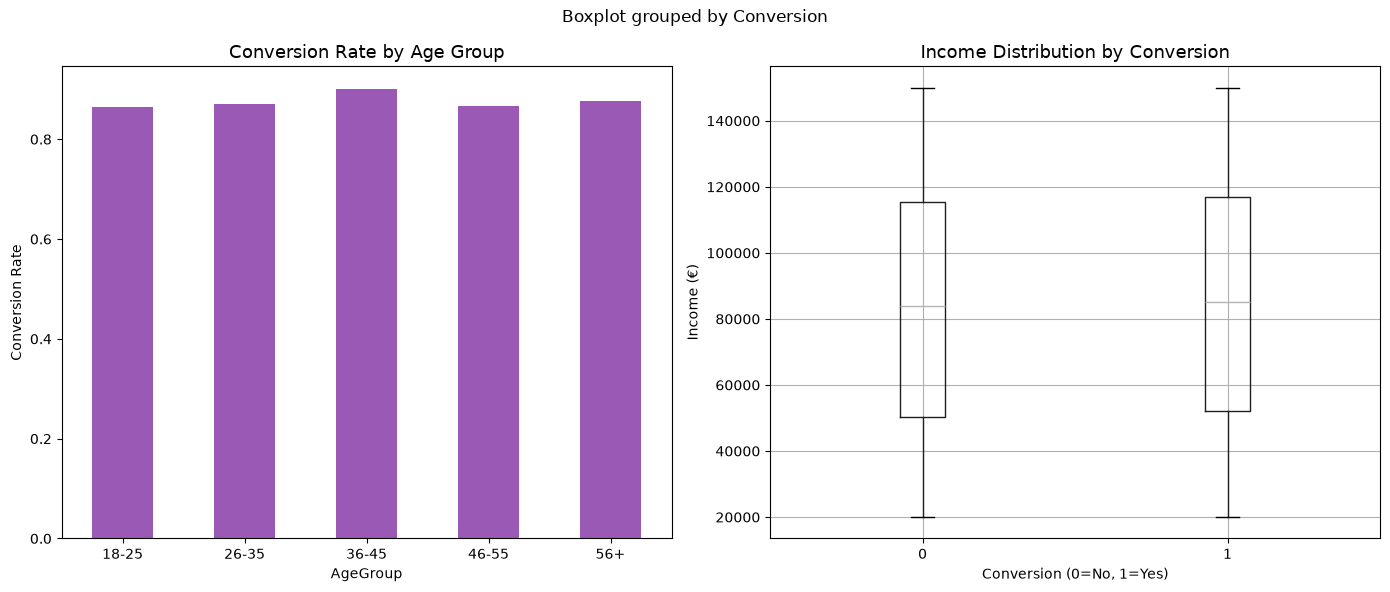

In [31]:
# Conversion by Age Group
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 100], labels=['18-25', '26-35', '36-45', '46-55', '56+'])

age_conversion = df.groupby('AgeGroup')['Conversion'].mean().round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

age_conversion.plot(kind='bar', ax=axes[0], color='#9b59b6')
axes[0].set_title('Conversion Rate by Age Group', fontsize=13)
axes[0].set_ylabel('Conversion Rate')
axes[0].tick_params(axis='x', rotation=0)

# Income vs Conversion
df.boxplot(column='Income', by='Conversion', ax=axes[1])
axes[1].set_title('Income Distribution by Conversion', fontsize=13)
axes[1].set_xlabel('Conversion (0=No, 1=Yes)')
axes[1].set_ylabel('Income (€)')

plt.tight_layout()
plt.show()

               ConversionRate  ClickThroughRate       AdSpend  Conversion
CampaignType                                                             
Consideration           0.105             0.152  9.861274e+06        1701
Conversion              0.105             0.156  1.030008e+07        1939
Awareness               0.104             0.156  1.007785e+07        1701
Retention               0.103             0.156  9.768362e+06        1671


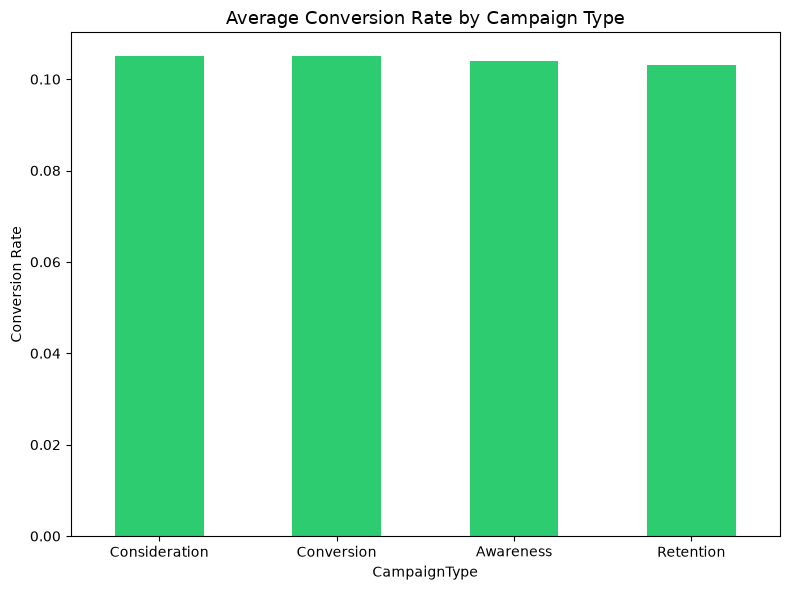

In [32]:
# Performance by Campaign Type (Awareness, Conversion, Retention)
type_summary = df.groupby('CampaignType').agg({
    'ConversionRate': 'mean',
    'ClickThroughRate': 'mean',
    'AdSpend': 'sum',
    'Conversion': 'sum'
}).round(3)

print(type_summary.sort_values('ConversionRate', ascending=False))

fig, ax = plt.subplots(figsize=(8, 6))
type_summary['ConversionRate'].sort_values(ascending=False).plot(kind='bar', ax=ax, color='#2ecc71')
ax.set_title('Average Conversion Rate by Campaign Type', fontsize=13)
ax.set_ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

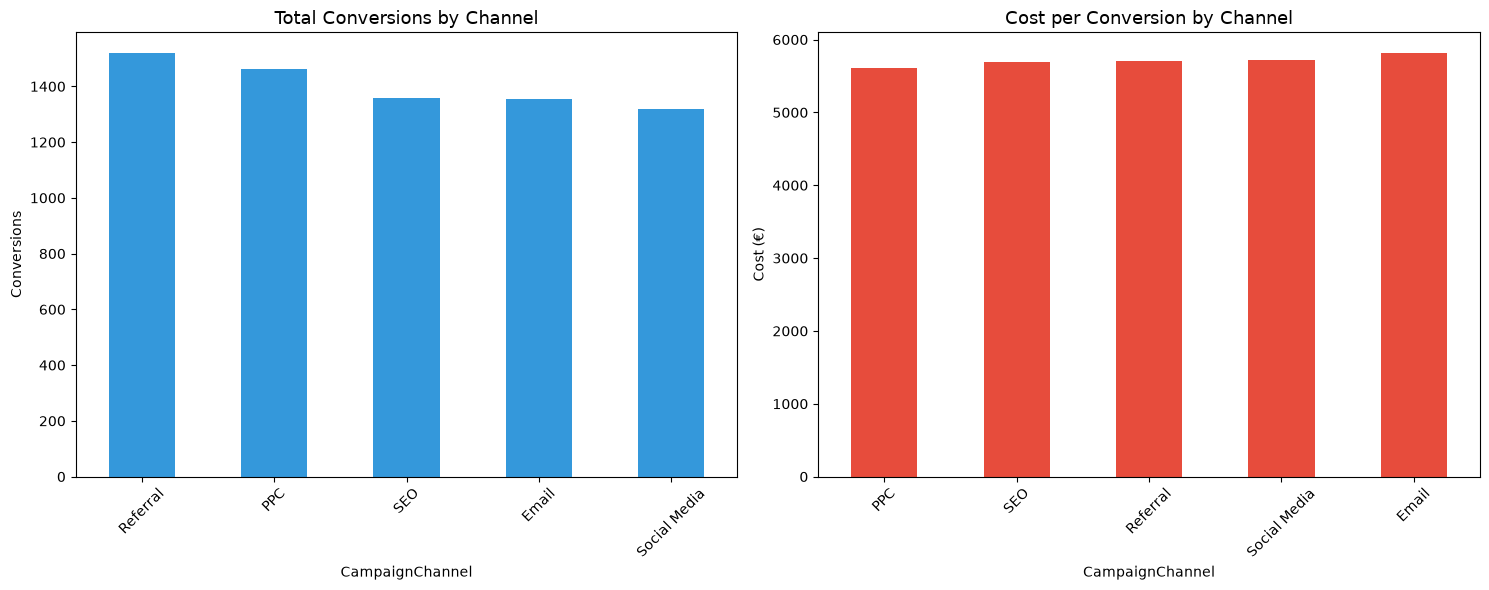

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Conversions by Channel
channel_summary['Total_Conversions'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Total Conversions by Channel', fontsize=13)
axes[0].set_ylabel('Conversions')
axes[0].tick_params(axis='x', rotation=45)

# Cost per Conversion by Channel
channel_summary['Cost_per_Conversion'].sort_values().plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('Cost per Conversion by Channel', fontsize=13)
axes[1].set_ylabel('Cost (€)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [34]:
# Conversion Rate & Performance by Campaign Channel
channel_summary = df.groupby('CampaignChannel').agg({
    'AdSpend': 'sum',
    'ClickThroughRate': 'mean',
    'ConversionRate': 'mean',
    'Conversion': 'sum',
    'CustomerID': 'count'
}).round(3)

channel_summary.columns = ['Total_AdSpend', 'Avg_CTR', 'Avg_ConversionRate', 'Total_Conversions', 'Total_Customers']
channel_summary['Cost_per_Conversion'] = (channel_summary['Total_AdSpend'] / channel_summary['Total_Conversions']).round(2)

print(channel_summary.sort_values('Total_Conversions', ascending=False))

                 Total_AdSpend  Avg_CTR  Avg_ConversionRate  \
CampaignChannel                                               
Referral           8653518.686    0.152               0.103   
PPC                8199236.981    0.158               0.104   
SEO                7740903.876    0.153               0.104   
Email              7871575.852    0.156               0.105   
Social Media       7542323.249    0.156               0.107   

                 Total_Conversions  Total_Customers  Cost_per_Conversion  
CampaignChannel                                                           
Referral                      1518             1719              5700.61  
PPC                           1461             1655              5612.07  
SEO                           1359             1550              5696.03  
Email                         1355             1557              5809.28  
Social Media                  1319             1519              5718.21  


In [35]:
print(df.columns.tolist())
df.info()
df.describe()

['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel', 'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'AdvertisingPlatform', 'AdvertisingTool', 'Conversion', 'AgeGroup']
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   CustomerID           8000 non-null   int64   
 1   Age                  8000 non-null   int64   
 2   Gender               8000 non-null   str     
 3   Income               8000 non-null   int64   
 4   CampaignChannel      8000 non-null   str     
 5   CampaignType         8000 non-null   str     
 6   AdSpend              8000 non-null   float64 
 7   ClickThroughRate     8000 non-null   float64 
 8   ConversionRate       8000 non-null   float64 
 9   WebsiteVisits

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('digital_marketing_campaign_dataset.csv')

print(df.shape)
print(df.columns.tolist())
df.head()

(8000, 20)
['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel', 'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'AdvertisingPlatform', 'AdvertisingTool', 'Conversion']


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1
